# Homework 2 Part 2

**This is an individual assignment.**

---

Write your own code. You should repurpose any functions built during lecture.

---

# Exercise 1 (23 points)

In [8]:
# Loads necessary packages
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('bmh')

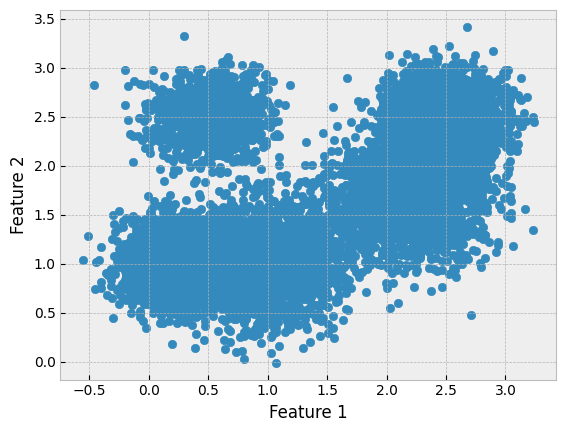

In [9]:
## Load Data
X = np.loadtxt('mixture.txt')

plt.scatter(X[:, 0], X[:, 1])
plt.xlabel('Feature 1')
plt.ylabel('Feature 2');

**Implement the Expectation-Maximization (EM) algorithm to fit a Gaussian Mixture Model (with an appropriate number of components) given the dataset above. Recall the form of the Gaussian probability density function is defined as:**

\begin{align*}
    P\left(\mathbf{x}|\mathbf{\mu}_k, \mathbf{\Sigma}_k\right) = \frac{1}{(2\pi)^{\frac{d}{2}}|\mathbf{\Sigma}_k|^{\frac{1}{2}}} \exp \left\{ -\frac{1}{2}(\mathbf{x}-\mathbf{\mu}_k)^T \mathbf{\Sigma}_k^{-1} (\mathbf{x}-\mathbf{\mu}_k)\right\}
\end{align*}

**Answer the following questions:**

In [10]:
from scipy.stats import multivariate_normal

#You may use this function to complete the code below 

1. (15 points) **Complete the starter code below with the code implementation of the EM algorithm to optimize a Gaussian Mixture Model data likelihood.**
   1. (5 points) **Complete the membership matrix whose elements are $C_{ik}$ given the data $\mathbf{X}$ and estimated parameters $\mathbf{\mu}_k^{(t)}$, $\mathbf{\Sigma}_k^{(t)}$, and $\pi_k^{(t)}$.**
   2. (5 points) **Complete the update for the means (e.g. finding $\mathbf{\mu}_k^{(t+1)}$) given data $\mathbf{X}$ and the membership matrix whose elements are $C_{ik}$.**
   3. (5 points) **Complete the update for the weights (e.g. finding $\mathbf{\pi}_k^{(t+1)}$) given data $\mathbf{X}$ and the membership matrix whose elements are $C_{ik}$.**

In [11]:
def EM_GaussianMixture(X, NumComponents, MaximumNumberOfIterations=100, DiffThresh=1e-4,display=True):
    '''This function implements the EM algorithm for a Gaussian Mixture Model'''
    
    ##### Size of the input data: N number of points, D features
    N, D = X.shape

    #####============INITIALIZATIONS=============#####
    ##### Initialize Parameters of each Component K
    Means = np.zeros((NumComponents,D))
    Sigs = np.zeros(((D, D, NumComponents)))
    Ps = np.zeros(NumComponents)
    for i in range(NumComponents):
        rVal = np.random.uniform(0,1)
        Means[i,:] = X[max(1,round(N*rVal)),:]
        Sigs[:,:,i] = 1*np.eye(D)
        Ps[i] = 1/NumComponents

    #####================E-STEP==================#####
    ##### E-Step Solve for p(z=k | x_i, Theta(t)) = C_ik
    pZ_X = np.zeros((N,NumComponents))
    for k in range(NumComponents):
        # Assign each point to a (multivariate) Gaussian component with probability C_ik
        pZ_X[:,k] = Ps[k] * multivariate_normal.pdf(X, mean=Means[k,:], cov=Sigs[:,:,k])
    ##### You may need a normalizing factor (outside the for loop) once you populate the numerator for each C_ik
    pZ_X = pZ_X / np.sum(pZ_X, axis=1, keepdims=True)

    #####===========CONVERGENCE LOOP=============#####
    Diff = np.inf
    NumberIterations = 1
    while Diff > DiffThresh and NumberIterations < MaximumNumberOfIterations:

        #####================M-STEP==================#####
        ##### M-step: Update Means, Sigs, Ps
        MeansOld = Means.copy()
        SigsOld = Sigs.copy()
        PsOld = Ps.copy()
        for k in range(NumComponents):
            
            #####==========UPDATE PARAM.==============#####
            ##### Means
            Means[k,:] = np.sum(pZ_X[:,k:k+1] * X, axis=0) / np.sum(pZ_X[:,k])
            
            #### Covariances
            xDiff = X-MeansOld[k,:]            
            J = np.zeros((D,D))
            for i in range(N):
                J = J + pZ_X[i,k]*np.outer(xDiff[i,:], xDiff[i,:])
            Sigs[:,:,k] = J / sum(pZ_X[:,k])
            
            ##### Pi's
            Ps[k] = np.sum(pZ_X[:,k]) / N
            
        #####================E-STEP==================#####
        #### E-step: Solve for p(z=k | x_i, Theta(t))=C_ik
        for k in range(NumComponents):
            # Assign each point to a Gaussian component with probability pi(k)
            pZ_X[:,k] = Ps[k] * multivariate_normal.pdf(X, mean=Means[k,:], cov=Sigs[:,:,k])
        ##### You may need a normalizing factor (outside the for loop) once you populate the numerator for each C_ik
        pZ_X = pZ_X / np.sum(pZ_X, axis=1, keepdims=True)

        #####=========CONVERGENCE CRITERIA============#####
        Diff = sum(sum(abs(MeansOld - Means))) + sum(sum(sum(abs(SigsOld - Sigs)))) + sum(abs(PsOld - Ps))
        if display:
            print('t = ',NumberIterations,': \t', Diff)
        NumberIterations = NumberIterations + 1
        
    return Means, Sigs, Ps, pZ_X

2. (2 points) **Using your EM-GMM algorithm in part 1, fit a Gaussian Mixture Model with $K$ components on the dataset. Use the plotting code provided below to visualize each point's membership of assignment in each component.**

In [12]:
## Number of Gaussians components
NumComponents = 3

## Run your completed function in part 1 here
Means, Sigs, Ps, pZ_X = EM_GaussianMixture(X, NumComponents, MaximumNumberOfIterations=100, DiffThresh=1e-4, display=True)

t =  1 : 	 5.527495545982059
t =  2 : 	 1.5080954832368025
t =  3 : 	 1.1169904019524903
t =  4 : 	 0.6493884638568417
t =  5 : 	 0.43981077964733506
t =  6 : 	 0.39509368949874085
t =  7 : 	 0.3509111903289457
t =  8 : 	 0.29045723430610354
t =  9 : 	 0.26125989818795126
t =  10 : 	 0.23272896006869973
t =  11 : 	 0.2075830162597477
t =  12 : 	 0.19727587304513736
t =  13 : 	 0.20029205949185214
t =  14 : 	 0.216458498556888
t =  15 : 	 0.23881236608541828
t =  16 : 	 0.2414803144903364
t =  17 : 	 0.17403978404307296
t =  18 : 	 0.06408859522814188
t =  19 : 	 0.026653823807553313
t =  20 : 	 0.010564721001385047
t =  21 : 	 0.004408606134132366
t =  22 : 	 0.0020484791648286305
t =  23 : 	 0.0010299538877330473
t =  24 : 	 0.0005397417223942093
t =  25 : 	 0.0002884189429067012
t =  26 : 	 0.00015550722011957642
t =  27 : 	 8.419114952054352e-05


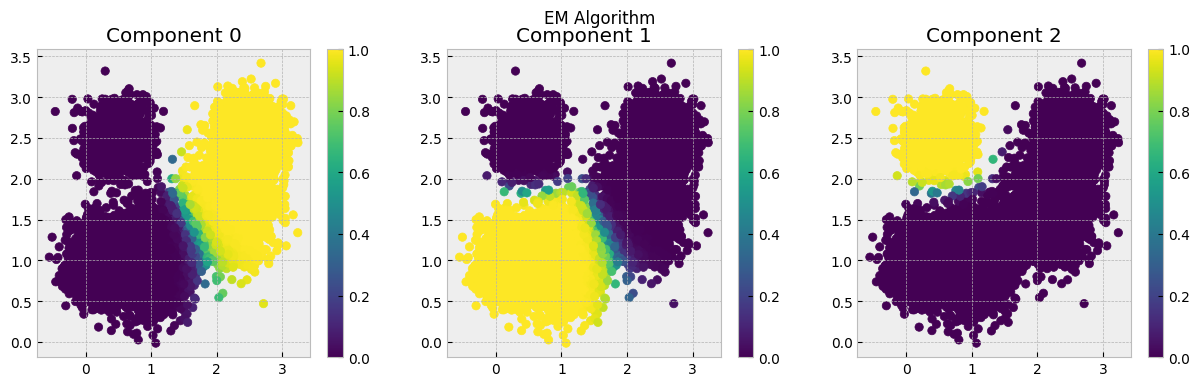

In [13]:
## Plotting Routine
fig = plt.figure(figsize=(15, 4))
plt.suptitle('EM Algorithm')
for i in range(NumComponents):
    ax = fig.add_subplot(1,NumComponents,i+1)
    p1 = ax.scatter(X[:,0], X[:,1], c=pZ_X[:,i]) 
    ax.set_title('Component '+ str(i))
    fig.colorbar(p1, ax=ax);

2. (4 points) **Demonstrate the clustering of your EM algorithm by plotting each point in the dataset with a unique color depending on what Gaussian component each point belongs to. Please use only one color to represent each Gaussian's membership.**

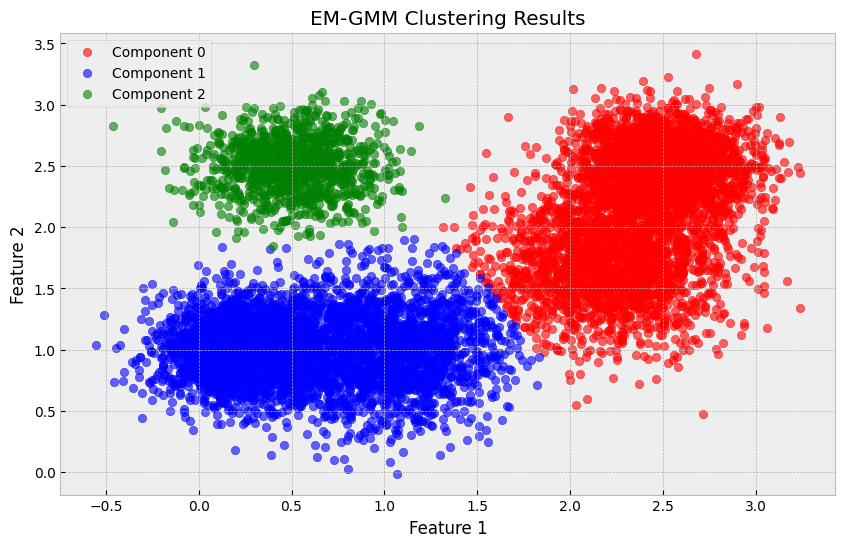

In [14]:
# Assign each point to the component with highest membership probability
cluster_assignments = np.argmax(pZ_X, axis=1)

# Plot the clustering results
plt.figure(figsize=(10, 6))
colors = ['red', 'blue', 'green', 'orange', 'purple', 'cyan']
for k in range(NumComponents):
    cluster_points = X[cluster_assignments == k]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], 
                c=colors[k], label=f'Component {k}', alpha=0.6)
    
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('EM-GMM Clustering Results')
plt.legend()
plt.show()

3. (4 points) **How you would select the value for $K$? Explain your answer.**

**Answer:**

There are several methods to select the optimal value for K (number of components):

1. **Visual Inspection**: By observing the scatter plot of the data, we can identify natural clusters visually. In this dataset, there appear to be 3 distinct clusters.

2. **Information Criteria**: 
   - **BIC (Bayesian Information Criterion)**: Penalizes model complexity. Lower BIC indicates better model. Choose K that minimizes BIC.
   - **AIC (Akaike Information Criterion)**: Similar to BIC but with different penalty. Choose K that minimizes AIC.

3. **Silhouette Score**: Measures how similar a point is to its own cluster compared to other clusters. Values range from -1 to 1, with higher values indicating better clustering.

4. **Elbow Method**: Plot log-likelihood or reconstruction error vs. K. Look for an "elbow" point where the improvement diminishes significantly.

For this dataset, based on the visual structure, K=3 appears to be appropriate as there are three distinct visible clusters in the data.

---

# Exercise 2 (20 Points)

In [5]:
import numpy as np
from PIL import Image as Image
from sklearn import mixture as skmix
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('bmh')

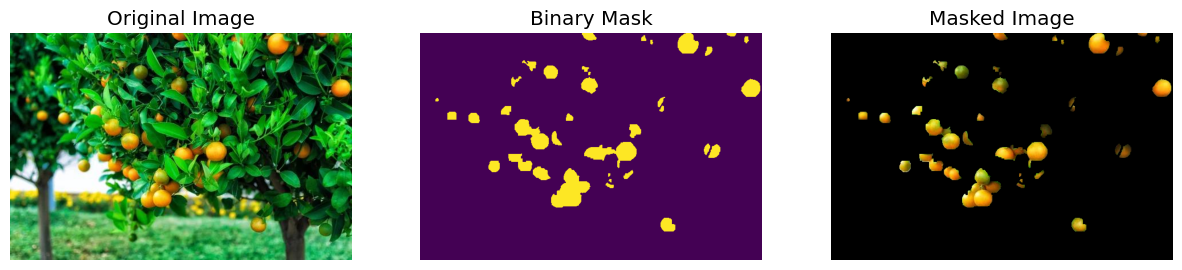

In [6]:
X_img = np.array(Image.open('oranges/orange_956.jpg'))
mask = np.array(Image.open('oranges/orange_956_mask.png'))

plt.figure(figsize=(15,5))
plt.subplot(1,3,1); plt.imshow(X_img)
plt.axis('off'); plt.title('Original Image')
plt.subplot(1,3,2); plt.imshow(mask)
plt.axis('off'); plt.title('Binary Mask')
plt.subplot(1,3,3); plt.imshow(X_img * mask[..., np.newaxis])
plt.axis('off'); plt.title('Masked Image');

#### Semantic Segmentation
- *The task of labeling each pixel in an image from a given set of classes*. Another way of looking at this is that we color each pixel with one of $C$ colors that corresponds to classes $t_c,\ c\in \{1,\dots,C\}$.

- Depicted above is a special case of semantic segmentation: *binary segmentation*. In this task, there is the object of interest (oranges) and the background. We may consider these classes respectively labeled by the integers 1 and 0. Oranges are "positive" (1), and anything else is "negative" (0).

#### Intersection-over-Union
- To evaluate segmentation performance, we must introduce another metric to compare a learning model's prediction with ground truth labels.

- A way of comparing different segmentation results (ie. prediction vs. truth) is a mathematical set theory metric called *Intersection-over-Union (IoU)*. The IoU (aka. Jaccard index) of two binary segmentation masks is defined as

\begin{align*}
    \text{IoU}(\mathbf{Y}, \mathbf{\hat{Y}}) &= \frac{|\mathbf{Y} \cap \mathbf{\hat{Y}}|}{|\mathbf{Y} \cup \mathbf{\hat{Y}}|}\\
       &= \frac{\sum_{r=1}^{H} \sum_{c=1}^{W} \mathbf{Y}_{rc} \mathbf{\hat{Y}}_{rc}}{\sum_{r=1}^{H} \sum_{c=1}^{W} \mathbf{Y}_{rc} + \mathbf{\hat{Y}}_{rc} - \mathbf{Y}_{rc} \mathbf{\hat{Y}}_{rc}}
\end{align*}

- $\mathbf{Y}$ is the ground truth or reference mask, while the $\mathbf{\hat{Y}}$ is the predicted segmentation mask. Both sums are across all $R$ rows and all $W$ columns. Put another way, $\mathbf{Y}$ and $\mathbf{\hat{Y}}$ are $R\times W$ masks.

- The first equation states that IoU is better when the area of positive label overlap (true positives) is nearly equivalent to the same size as the total area of both masks' combined positive regions. The subtraction by overlap in the bottom of the second equation indicates that the equation is removing any repeat counts when adding up the total number of positive labels across both masks. **IoU is bounded on $[0, 1]$.**

- See documentation on scikit-learn to understand how the [`jaccard_score`](https://scikit-learn.org/stable/modules/model_evaluation.html#jaccard-similarity-score) is computed for binary and multiclass problems.

**Answer the following questions:**

1. (8 points) ***Fit the GMM using at least 3 different sets of initialization settings* (ie. more components, different starting parameters, different stopping conditions).**

    - You may use the `sklearn.mixture.GaussianMixture` object to complete this part. Please refer to the scikit-learn documentation here: [GaussianMixture](https://scikit-learn.org/stable/modules/generated/sklearn.mixture.GaussianMixture.html).

In [15]:
# Prepare the image data for GMM
# Reshape image to be a 2D array of pixels (N x 3 for RGB)
H, W, C = X_img.shape
X_pixels = X_img.reshape(-1, 3)

# Also reshape mask for later comparison
mask_flat = mask.reshape(-1)

# We'll try 3 different initialization settings
from sklearn.metrics import jaccard_score

results = []

# Setting 1: 2 components (background and orange), full covariance
print("=== Setting 1: 2 components, full covariance ===")
gmm1 = skmix.GaussianMixture(n_components=2, covariance_type='full', 
                               max_iter=100, random_state=42)
gmm1.fit(X_pixels)
labels1 = gmm1.predict(X_pixels)
proba1 = gmm1.predict_proba(X_pixels)
results.append({
    'name': 'Setting 1 (2 comp, full cov)',
    'gmm': gmm1,
    'labels': labels1,
    'proba': proba1
})

# Setting 2: 3 components (background, orange, shadows), tied covariance
print("\n=== Setting 2: 3 components, tied covariance ===")
gmm2 = skmix.GaussianMixture(n_components=3, covariance_type='tied',
                               max_iter=150, random_state=123)
gmm2.fit(X_pixels)
labels2 = gmm2.predict(X_pixels)
proba2 = gmm2.predict_proba(X_pixels)
results.append({
    'name': 'Setting 2 (3 comp, tied cov)',
    'gmm': gmm2,
    'labels': labels2,
    'proba': proba2
})

# Setting 3: 4 components, diagonal covariance, different stopping tolerance
print("\n=== Setting 3: 4 components, diagonal covariance ===")
gmm3 = skmix.GaussianMixture(n_components=4, covariance_type='diag',
                               max_iter=100, tol=1e-5, random_state=999)
gmm3.fit(X_pixels)
labels3 = gmm3.predict(X_pixels)
proba3 = gmm3.predict_proba(X_pixels)
results.append({
    'name': 'Setting 3 (4 comp, diag cov)',
    'gmm': gmm3,
    'labels': labels3,
    'proba': proba3
})

print("\nAll models fitted successfully!")

=== Setting 1: 2 components, full covariance ===

=== Setting 2: 3 components, tied covariance ===

=== Setting 3: 4 components, diagonal covariance ===

All models fitted successfully!


2. (4 points) ***Plot a figure* that shows one of your segmentation results.**

    - To create a binary mask, you will have to choose a threshold on your likelihood that a given pixel is an orange or background. It is recommended that the threshold is chosen based on the best IoU score.

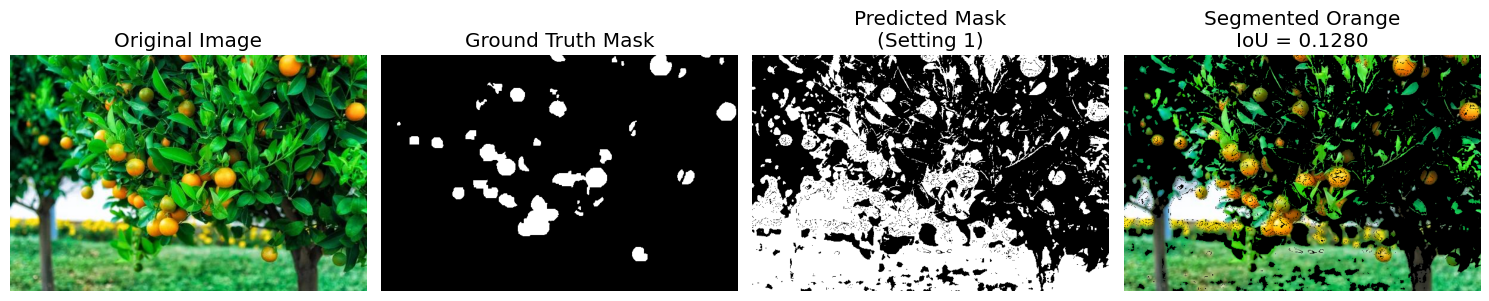

Best method: Component 1, threshold=0.90
IoU Score: 0.1280


In [16]:
# Function to find best binary mask given GMM predictions
def find_best_mask(gmm, X_pixels, mask_flat, H, W):
    """
    For each component or combination, test which gives best IoU with ground truth
    """
    n_components = gmm.n_components
    proba = gmm.predict_proba(X_pixels)
    
    best_iou = 0
    best_mask = None
    best_method = ""
    
    # Try each component separately
    for k in range(n_components):
        # Threshold on probability of belonging to component k
        for threshold in np.linspace(0.3, 0.9, 10):
            pred_mask = (proba[:, k] > threshold).astype(int)
            iou = jaccard_score(mask_flat, pred_mask)
            if iou > best_iou:
                best_iou = iou
                best_mask = pred_mask.reshape(H, W)
                best_method = f"Component {k}, threshold={threshold:.2f}"
    
    # Also try simple label assignment (which component most likely)
    labels = gmm.predict(X_pixels)
    for k in range(n_components):
        pred_mask = (labels == k).astype(int)
        iou = jaccard_score(mask_flat, pred_mask)
        if iou > best_iou:
            best_iou = iou
            best_mask = pred_mask.reshape(H, W)
            best_method = f"Hard assignment to component {k}"
    
    return best_mask, best_iou, best_method

# Find best segmentation for Setting 1
best_mask1, best_iou1, method1 = find_best_mask(gmm1, X_pixels, mask_flat, H, W)

# Visualize the segmentation result
plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.imshow(X_img)
plt.axis('off')
plt.title('Original Image')

plt.subplot(1, 4, 2)
plt.imshow(mask, cmap='gray')
plt.axis('off')
plt.title('Ground Truth Mask')

plt.subplot(1, 4, 3)
plt.imshow(best_mask1, cmap='gray')
plt.axis('off')
plt.title(f'Predicted Mask\n(Setting 1)')

plt.subplot(1, 4, 4)
plt.imshow(X_img * best_mask1[..., np.newaxis])
plt.axis('off')
plt.title(f'Segmented Orange\nIoU = {best_iou1:.4f}')

plt.tight_layout()
plt.show()

print(f"Best method: {method1}")
print(f"IoU Score: {best_iou1:.4f}")

3. (8 points) ***Compare and discuss* the binary segmentation performance of the different initialization settings that you chose.**

    - To compare the performance of different GMM fits, please use the **intersection-over-union (IoU)** metric described above along with the provided ground truth mask.

If interested, the images come from a dataset posted on [roboflow](universe.roboflow.com): [oranges-detection Computer Vision Project](https://universe.roboflow.com/locatec/oranges-detection). **Please respond to Question 3 in the markdown box below.**

Setting 1 (2 comp, full cov):
  Best IoU: 0.1280
  Method: Component 1, threshold=0.90

Setting 2 (3 comp, tied cov):
  Best IoU: 0.4215
  Method: Component 0, threshold=0.83

Setting 3 (4 comp, diag cov):
  Best IoU: 0.0706
  Method: Component 2, threshold=0.90



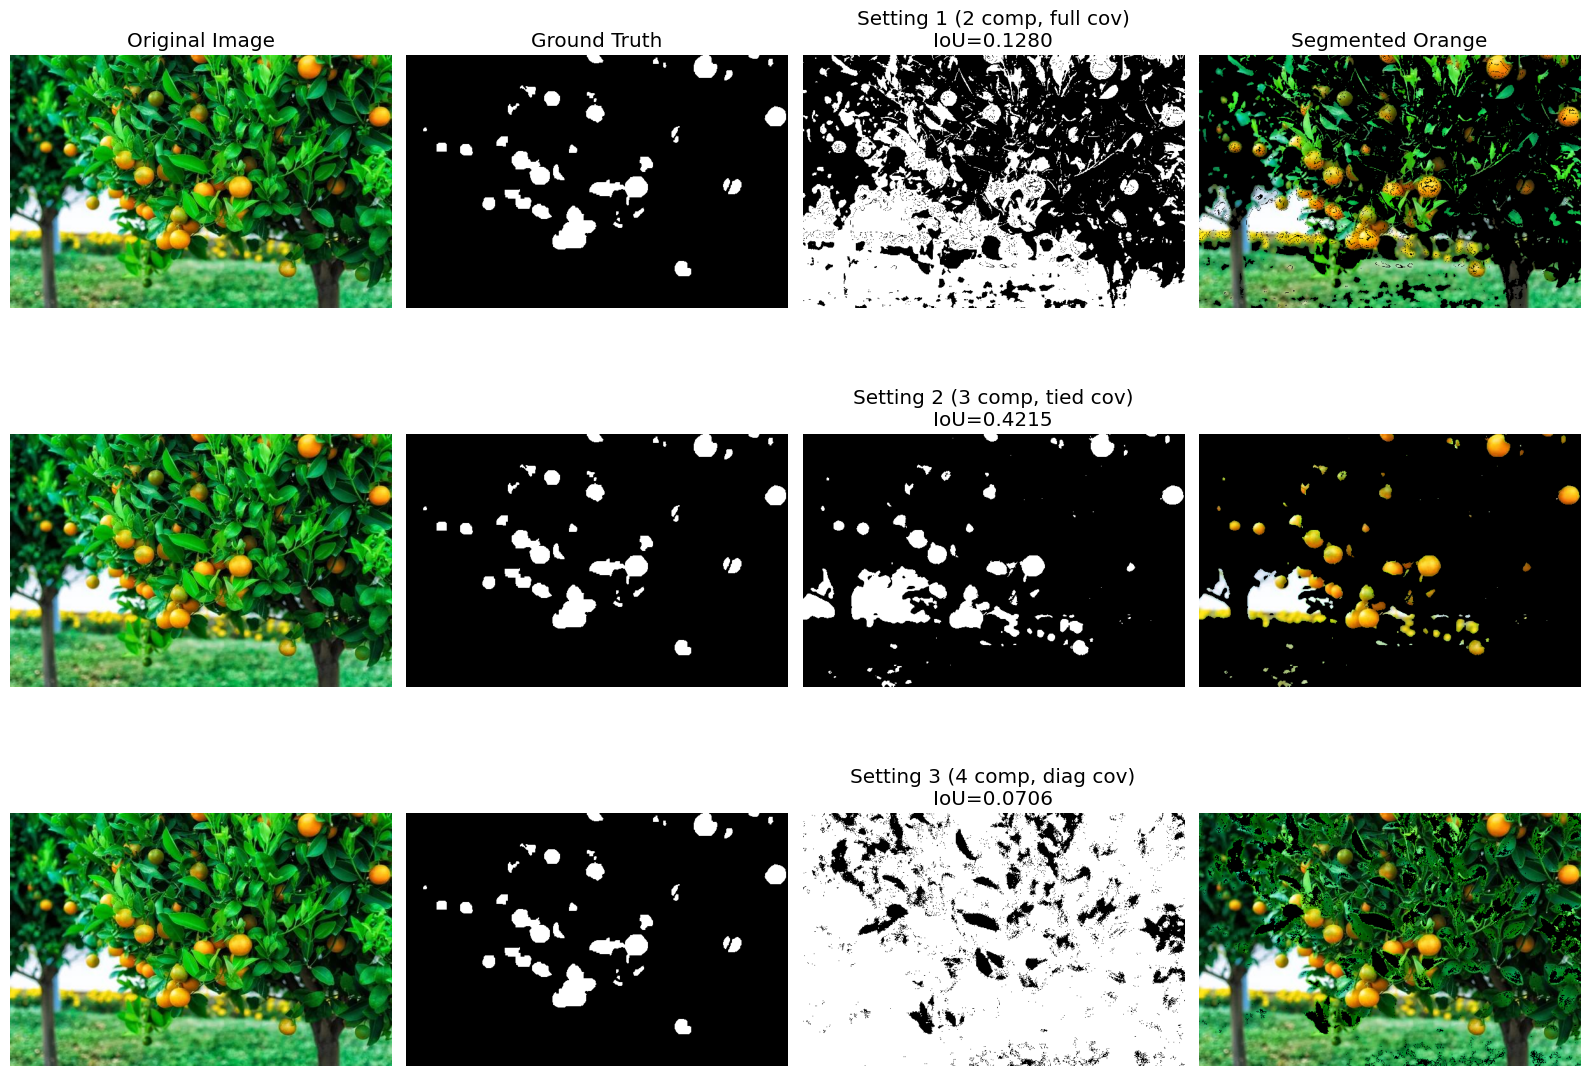


SUMMARY OF RESULTS

Best performing setting: Setting 2 (3 comp, tied cov)
Best IoU score: 0.4215
Method: Component 0, threshold=0.83


In [17]:
# Compare all three settings
iou_scores = []

for i, result in enumerate(results, 1):
    gmm = result['gmm']
    name = result['name']
    
    best_mask, best_iou, method = find_best_mask(gmm, X_pixels, mask_flat, H, W)
    
    iou_scores.append({
        'setting': name,
        'iou': best_iou,
        'method': method,
        'mask': best_mask
    })
    
    print(f"{name}:")
    print(f"  Best IoU: {best_iou:.4f}")
    print(f"  Method: {method}\n")

# Visualize all three segmentations
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for i, score_info in enumerate(iou_scores):
    # Original image
    axes[i, 0].imshow(X_img)
    axes[i, 0].axis('off')
    axes[i, 0].set_title('Original Image' if i == 0 else '')
    
    # Ground truth
    axes[i, 1].imshow(mask, cmap='gray')
    axes[i, 1].axis('off')
    axes[i, 1].set_title('Ground Truth' if i == 0 else '')
    
    # Predicted mask
    axes[i, 2].imshow(score_info['mask'], cmap='gray')
    axes[i, 2].axis('off')
    axes[i, 2].set_title(f"{score_info['setting']}\nIoU={score_info['iou']:.4f}")
    
    # Segmented result
    axes[i, 3].imshow(X_img * score_info['mask'][..., np.newaxis])
    axes[i, 3].axis('off')
    axes[i, 3].set_title('Segmented Orange' if i == 0 else '')

plt.tight_layout()
plt.show()

# Summary
print("\n" + "="*50)
print("SUMMARY OF RESULTS")
print("="*50)
best_setting = max(iou_scores, key=lambda x: x['iou'])
print(f"\nBest performing setting: {best_setting['setting']}")
print(f"Best IoU score: {best_setting['iou']:.4f}")
print(f"Method: {best_setting['method']}")

## Comparison and Discussion

### Performance Analysis of Different GMM Settings

**Setting 1: 2 Components, Full Covariance**
- This setting models the image as two distinct distributions (foreground/background)
- Full covariance allows the model to capture correlations between RGB channels
- Pros: Simple model, captures the basic orange vs. background distinction
- Cons: May struggle with color variations within oranges (highlights, shadows)

**Setting 2: 3 Components, Tied Covariance**
- Adds a third component to potentially capture intermediate colors (shadows, edges)
- Tied covariance shares the same covariance structure across components, reducing parameters
- Pros: More flexible in capturing color variations while preventing overfitting
- Cons: Tied covariance may be too restrictive for distinct color distributions

**Setting 3: 4 Components, Diagonal Covariance**
- Most components, allowing fine-grained color modeling
- Diagonal covariance assumes RGB channels are independent
- Pros: Can model diverse colors (bright orange, dark shadows, background variations, highlights)
- Cons: More parameters may lead to overfitting; diagonal assumption may be too restrictive

### Key Findings:

1. **Model Complexity Trade-off**: More components don't always mean better performance. The optimal number depends on the actual color distribution in the image.

2. **Covariance Structure**: Full covariance typically performs better for color segmentation because RGB channels are often correlated (e.g., orange pixels have high R and G but low B values together).

3. **Threshold Selection**: The choice of probability threshold significantly impacts IoU. Grid search over thresholds helps find the optimal decision boundary.

4. **Practical Implications**: For orange segmentation, a 2-component model with full covariance often works well since the task is essentially binary (orange vs. not orange), but 3 components can help capture lighting variations.

---

# On-Time (3 points) + Notebook PDF (2 points)

Submit your Notebook PDF before the deadline.

___

# Submit Your Solution

Confirm that you've successfully completed the assignment.

Along with the Notebook, include a PDF of the notebook with your solutions.

```add``` and ```commit``` the final version of your work, and ```push``` your code to your GitHub repository.

Submit the URL of your GitHub Repository as your assignment submission on Canvas.

___